# Getting Started with Network Verification via Batfish

The calls to the verify question API for safety properties are as follows:
```
bf.q.safety(target=...,location=...,assumption_locations=...,assumptions=...,default_assumption=...,show_all=...,refine=...)
```

The `pybatfish` question is in development, so these inputs are currently just strings. For this reason, in this notebook and in the files `startup.py` and `verificationPythonSupport.py` I've included functions and classes to abstract some of the strings so that it is easier to use. The examples below make use of these classes and functions - there is a later cell specifying the API that is usable in this notebook.


In [1]:
# Run the setup and includes the API support for using pybatfish
%run startup.py

Below are some examples of the classes and calls that you can make. The remaining of the notebook will show different examples.

In [2]:
# A LocationPropertyPair consists of a location and a property which is represented as a DNF (disjunction of clauses) 
target_example = LocationPropertyPair(location="node1",property=[Clause(communities=[],prefixes=["!25.13.0.0/16"])])

# These are two assumptions at edges which come from external ips - the first is conjunction, second is disjunction
# A Clause takes two possible fields (communities and prefixes) which are interpreted as being conjoined, default if not provide is empty list
assumption_example_one = LocationPropertyPair(location="100.0.0.1 -> bordera",property=[Clause(communities=["10:10","!20:20"],prefixes=["10.20.0.0/16"])])
assumption_example_two = LocationPropertyPair(location="100.0.0.2 -> borderb",property=[Clause(prefixes=["!100.0.0.0/8"]),Clause(communities=["1:1"])])

# A Property is used to specify a default assumption - the constructor just takes a list of clauses (interpreted as a DNF as above)
default_assumption = Property([Clause(communities=["!10:10"],prefixes=[])])

# Below are the easiest ways to pass true as a Property or LocationPropertyPair, respectively
true_property = Property([])
true_location_pair = LocationPropertyPair(location="name",property=[])

query_with_no_assumptions = VerificationQuery(target=target_example,assumptions=[],refine=False)
query_with_assumptions = VerificationQuery(target=target_example,assumptions=[assumption_example_one,assumption_example_two])
query_with_assumptions_and_default = VerificationQuery(target=target_example,assumptions=[assumption_example_one],default=default_assumption)

The `show_all` flag indicates whether or not all inferred invariants should be displayed for the user. If this flag is False (which is the default), then only the target property and assumption locations' results will be displayed. If the flag is True, then all inferred invariants within the network are displayed. In the case that `show_all` is set to False and our inference infers False at some point, only this location is returned as a counterexample (along with the target property for reference).

The `refine` flag indicates if the invariants should be refined. The default value is False - resulting in no refinement. The goal of refinement is to simplify the invariants and tease out the aspects of these invariants which are crucial and responsible for verification. 

## Example One (with Result Explanation)
This example is a simple three-node network which is shown below. The property that we want to verify is that no traffic going from the `Border3` node (ip address of `10.0.0.3`) to the outside of the network (to `100.0.0.2`) has the prefix `25.13.0.0/16`. The goal is to do this by using the community `10:10` to tag this traffic coming from the node `100.0.0.1`. 

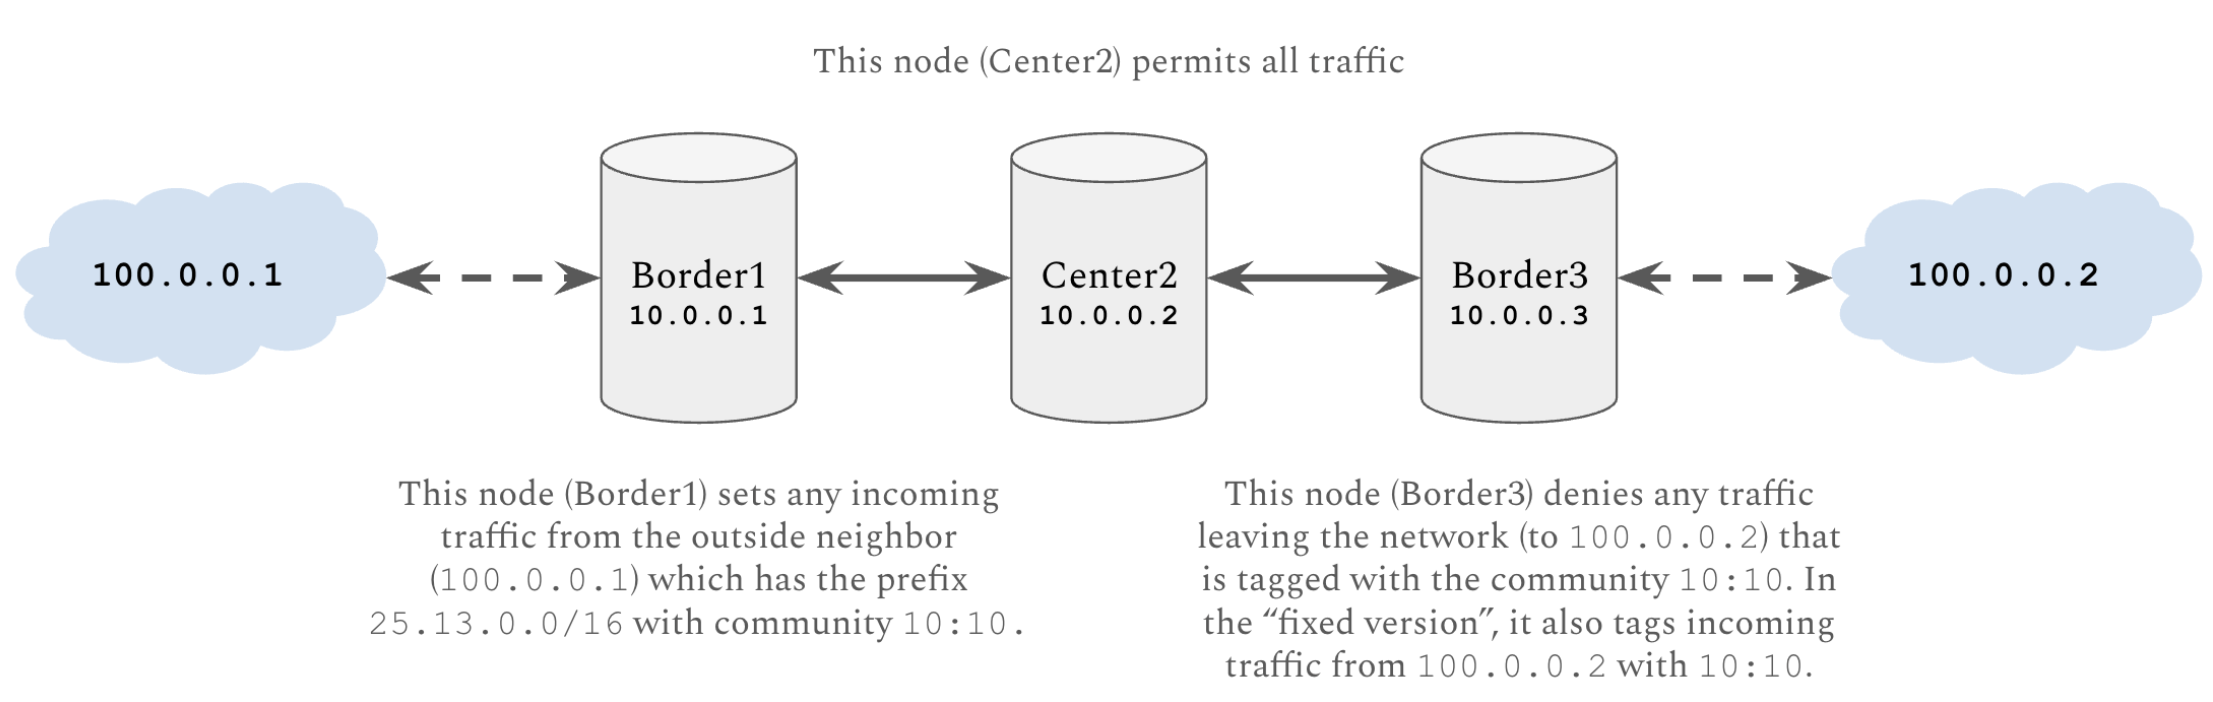

In [3]:
# Names for Batfish query
networkName = "exampleOne_network"
snapshotName = "exampleOne_snapshot"
snapshotPath = "snapshots/exampleOne"

# Target Property (and location for Target Property to hold at)
target = LocationPropertyPair(location="10.0.0.3 -> 100.0.0.2",property=[Clause(communities=[],prefixes=["!25.13.0.0/16"])])
# Specific assumption that should hold at provided location
assumption = LocationPropertyPair(location="100.0.0.1 -> border1",property=[Clause(communities=[],prefixes=["!25.13.0.0/16"])])
# Optional parameter to set the default assumption for incoming edges (if no default assumption is provided, we assume any traffic can enter)
default_assumption = Property([Clause(communities=["!10:10"],prefixes=[])])

# Query python object to hold the information we provide for query (refine's default is False)
query = VerificationQuery(target=target,assumptions=[assumption],default=default_assumption,refine=True)

# Try changing the show_all flag to be False to see how the results change (show_all's default is False)
runAndDisplay(networkName,snapshotName,snapshotPath,query,show_all=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,!prefix([25.13.0.0/16]),border3 -> 100.0.0.2,!prefix([25.13.0.0/16]),
1,Assumption,!comm(10:10),100.0.0.2 -> border3,!prefix(25.13.0.0/16) OR comm(10:10),Bgpv4Route{network=25.13.0.0/16}
2,Assumption,!prefix([25.13.0.0/16]),100.0.0.1 -> border1,true,
3,Intermediate,,"border3 -> center2, border3, center2 -> border3, center2 -> border1, border1, center2, border1 -> center2",!prefix(25.13.0.0/16) OR comm(10:10),


**Understanding the Results**

The <u>_Location Relevance_</u> column indicates what type of location this row pertains to. If this column has the value `Target`, then this row describes the property that is being verified - this will match the property and location provided by the user. If the column has the value `Assumption`, then this row corresponds to locations where there was some assumption that needs to be checked - usually for edges which are entering the network from the outside. If the column has the value `Intermediate`, then this row corresponds to locations that are within the network and have no assumption associated with them. 

There will only be rows with the _Location Relevance_ as `Intermediate` if the `show_all` flag is set to True (and so all inferred invariants are shown), or if the invariant inference produced False as an invariant at that location (in this case when the `show_all` flag is set to False), the only values returned are the counterexample where False was inferred and the target property). 

The <u>_Provided Invariant_</u> column holds the property to be verified (if the row is a `Target` row), or it holds the assumption provided (if the row is an `Assumption` row). `Intermediate` rows will have no provided invariants associated with them as it is the job of our algorithm to infer these invariants.

The <u>_Network Locations_</u> column holds all of the locations that meet the conditions expressed by that row. These are grouped together to concisely represent all locations which might end up having the same invariants provided, invariants inferred, and counterexample (if applicable).

The <u>_Inferred Invariant_</u> column holds the results of our inference. These are the invariants (refined if that flag was set) which are consistent with the verified property. That is, as long as these invariants locally hold at the specified locations, then the target property will hold.

Finally, the <u>_Counterexample_</u> column holds a route which is a counterexample at the corresponding locations. Explicitly, this is a route which satisfies the assumption at this location but does not satisfy the invariant which much hold in order for the target property to hold.

If there are no counterexamples (in the rightmost column), then the property is verified. Explicitly, if the _Provided Invariant_ in each column implies the _Inferred Invariant_ (in rows where there is a _Provided Invariant_), then the property is verifed.

The previous examples failed overall verification because even though the input edge from the ip address `100.0.0.1` infers the invariant true (implying an incoming traffic is ok), on the other end, we need to make sure that the prefix we are trying to avoid (`25.13.0.0/16`) doesn't come from the other outside incoming edge (`100.0.0.2 -> 10.0.0.3`). 

This assumption makes sense if we want to prove that routes with this prefix don't come out to the node `100.0.0.2`, then we would assume it wouldn't send those routes back into the network. This is updated in the following section by adding that any traffic coming in on the edge `10.0.0.3` from `100.0.0.2` does not have the prefix `25.13.0.0/16`. Alternatively, we can state that this traffic should be assumed to have a conflicting prefix (this is commented out).

In [4]:
networkName = "exampleOne_network"
snapshotName = "exampleOne_snapshot"
snapshotPath = "snapshots/exampleOne"
target = LocationPropertyPair(location="border3 -> 100.0.0.2",property=[Clause(communities=[],prefixes=["!25.13.0.0/16"])])
assumption = LocationPropertyPair(location="100.0.0.2 -> border3",property=[Clause(communities=[],prefixes=["!25.13.0.0/16"])])
query = VerificationQuery(target=target,assumptions=[assumption],refine=True)
runAndDisplay(networkName,snapshotName,snapshotPath,query,show_all=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,!prefix([25.13.0.0/16]),border3 -> 100.0.0.2,!prefix([25.13.0.0/16]),
1,Assumption,!prefix([25.13.0.0/16]),100.0.0.2 -> border3,!prefix([25.13.0.0/16]),
2,Assumption,true,100.0.0.1 -> border1,true,
3,Intermediate,,"border3 -> center2, border3, center2 -> border3, center2 -> border1, border1, center2, border1 -> center2",!prefix(25.13.0.0/16) OR comm(10:10),


Another way to fix this network is to say that any incoming traffic (to the node `10.0.0.3`) from the outside nodes (in this example that is `100.0.0.2`) is also tagged with the community. This would ensure that the traffic is not sent back to the outside node it was received from. This is shown in the example below. This is likely a better fix than the previous one because it makes no assumptions about traffic coming into the network.

In [5]:
networkName = "exampleOne_fixed_network"
snapshotName = "exampleOne_fixed_snapshot"
snapshotPath = "snapshots/exampleOneFixed"
target = LocationPropertyPair(location="10.0.0.3 -> 100.0.0.2",property=[Clause(communities=[],prefixes=["!25.13.0.0/16"])])
query = VerificationQuery(target=target,assumptions=[],refine=True)
runAndDisplay(networkName,snapshotName,snapshotPath,query,show_all=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,!prefix([25.13.0.0/16]),border3 -> 100.0.0.2,!prefix([25.13.0.0/16]),
1,Assumption,true,"100.0.0.1 -> border1, 100.0.0.2 -> border3",true,
2,Intermediate,,"border3 -> center2, border3, center2 -> border3, center2 -> border1, border1, center2, border1 -> center2",!prefix(25.13.0.0/16) OR comm(10:10),


## Example Two

This example is a network where the intent is to only permit outgoing traffic to `100.0.0.4` which has passed through both nodes "border1" and "border2." This is implemented by tagging routes with communities `100:1` and `100:2` when passing through "border1" and "border2" respectively. And then checking that if these communities are tagged in the middle node, then the community `100:3` is added (which is then used as a filter at the final border node "border4"). [There is a typo in the image below, the final node should say that it only permits traffic which is tagged with the community `100:3`.]

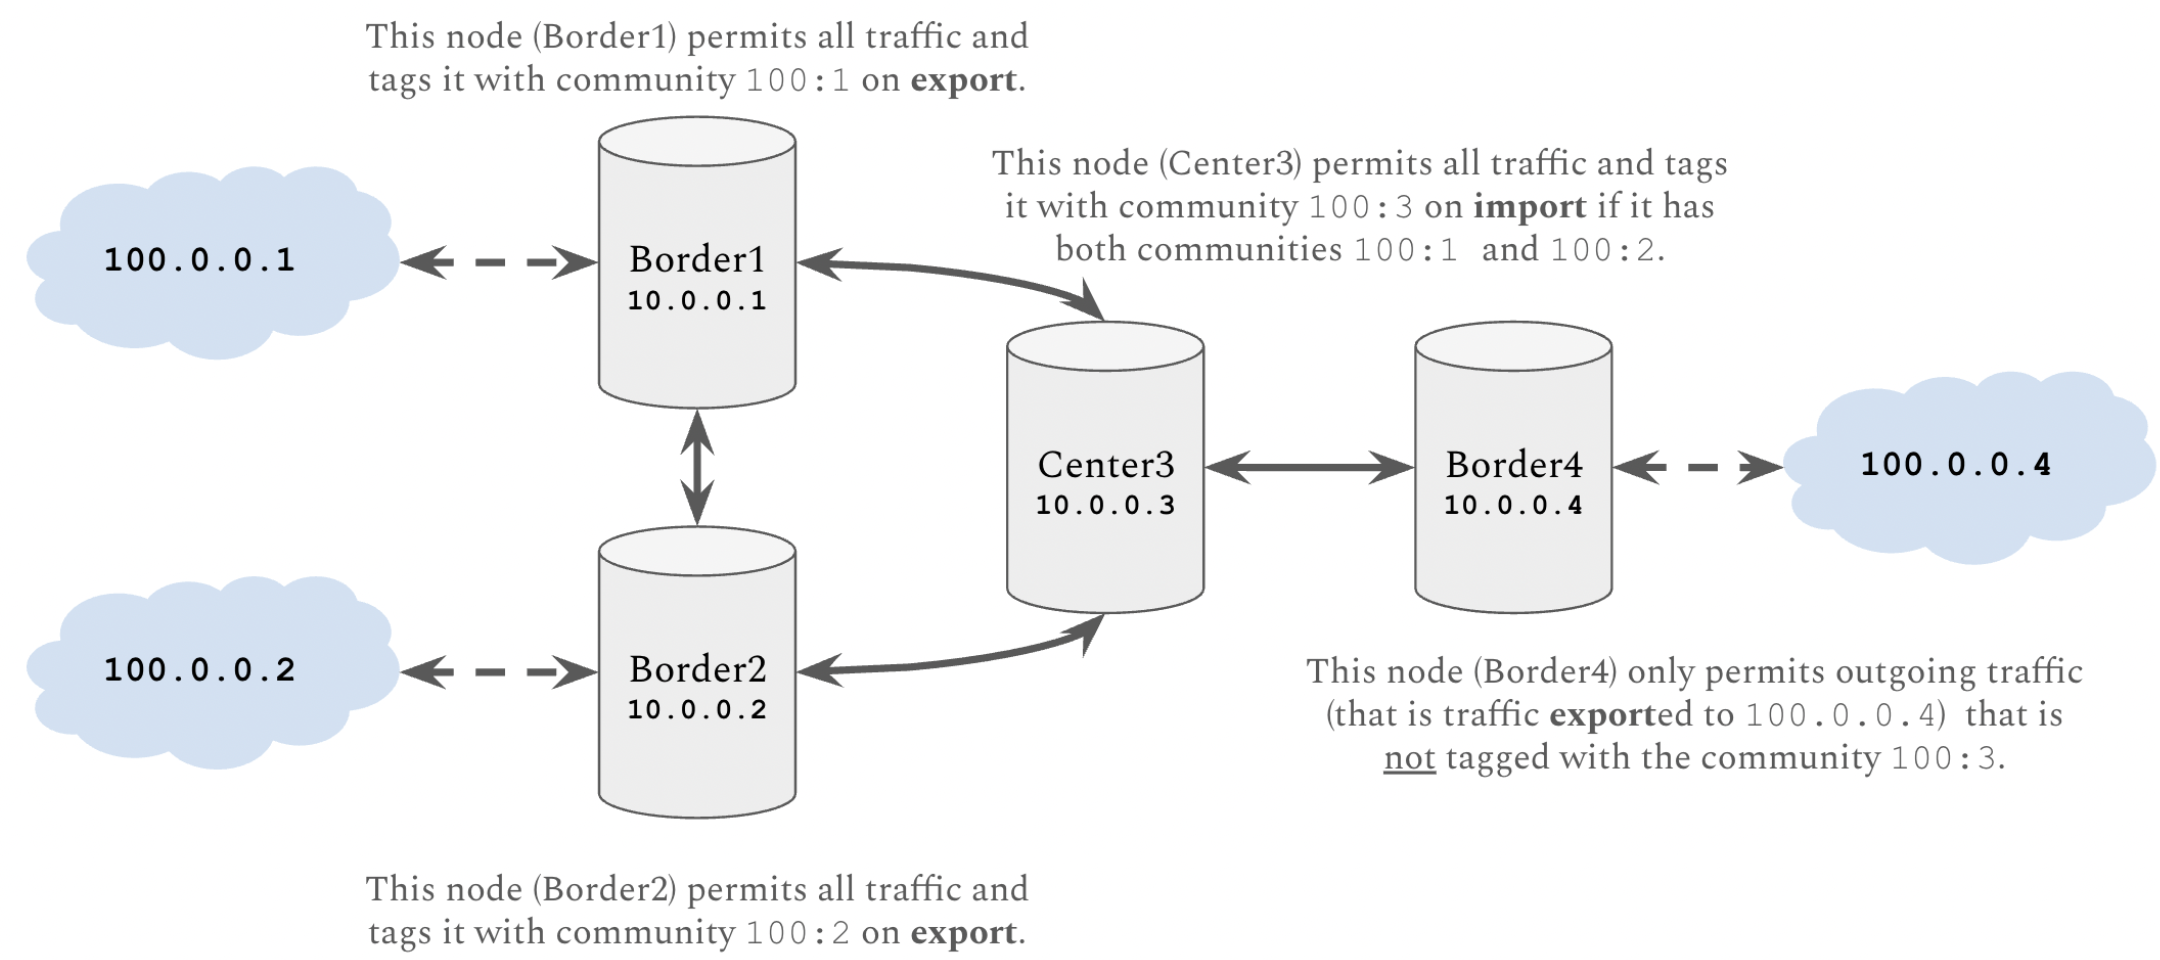

In [6]:
networkName = "exampleTwo_network"
snapshotName = "exampleTwo_snapshot"
snapshotPath = "snapshots/exampleTwo"
target = LocationPropertyPair(location="10.0.0.4 -> 100.0.0.4",property=[Clause(communities=["100:1","100:2"],prefixes=[])])
query = VerificationQuery(target=target,assumptions=[],refine=True)
runAndDisplay(networkName,snapshotName,snapshotPath,query,True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,"comm(100:1),comm(100:2)",border4 -> 100.0.0.4,"comm(100:1),comm(100:2)",
1,Assumption,true,100.0.0.4 -> border4,"!comm(100:1),!comm(100:3) OR !comm(100:2),!comm(100:3),comm(100:1) OR comm(100:1),comm(100:2)","Bgpv4Route{network=10.0.0.0/8, communities=CommunitySet{communities=[100:3]}}"
2,Assumption,true,100.0.0.1 -> border1,!comm(100:3) OR comm(100:2),"Bgpv4Route{network=10.0.0.0/8, communities=CommunitySet{communities=[100:3]}}"
3,Assumption,true,100.0.0.2 -> border2,!comm(100:3) OR comm(100:1),"Bgpv4Route{network=10.0.0.0/8, communities=CommunitySet{communities=[100:3]}}"
4,Intermediate,,"border4 -> center3, center3 -> border4, center3, border1 -> center3, border4, border2 -> center3","!comm(100:1),!comm(100:3) OR !comm(100:2),!comm(100:3),comm(100:1) OR comm(100:1),comm(100:2)",
5,Intermediate,,"border1, center3 -> border1, border2 -> border1",!comm(100:3) OR comm(100:2),
6,Intermediate,,"border2, center3 -> border2, border1 -> border2",!comm(100:3) OR comm(100:1),


This previous example fails because at the center node, initially we checked if the route had both communities`100:1` and `100:2` and flagged with `100:3` if so, else we permitted without modification. However, the subtle distinction is that the  routes coming out of this node should have the community `100:3` _if and only if_ it has both the communities `100:1` and `100:2`. The code below runs the example `exampleTwoBetter` which fixes this by stripping comunities at the center node (`10.0.0.3`) if the route does not have both `100:1` and `100:2` and has `100:3`.

In [7]:
networkName = "exampleTwo_better_network"
snapshotName = "exampleTwo_better_snapshot"
snapshotPath = "snapshots/exampleTwoBetter"
target = LocationPropertyPair(location="10.0.0.4 -> 100.0.0.4",property=[Clause(communities=["100:1","100:2"],prefixes=[])])
query = VerificationQuery(target=target,assumptions=[],refine=True)
runAndDisplay(networkName,snapshotName,snapshotPath,query,True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,"comm(100:1),comm(100:2)",border4 -> 100.0.0.4,"comm(100:1),comm(100:2)",
1,Assumption,true,"100.0.0.1 -> border1, 100.0.0.2 -> border2",true,
2,Assumption,true,100.0.0.4 -> border4,"!comm(100:1),!comm(100:3) OR !comm(100:2),!comm(100:3),comm(100:1) OR comm(100:1),comm(100:2)","Bgpv4Route{network=10.0.0.0/8, communities=CommunitySet{communities=[100:3]}}"
3,Intermediate,,"border4 -> center3, border2, center3 -> border2, border1, center3 -> border1, border1 -> center3, border1 -> border2, border2 -> center3, border2 -> border1",true,
4,Intermediate,,"center3 -> border4, center3, border4","!comm(100:1),!comm(100:3) OR !comm(100:2),!comm(100:3),comm(100:1) OR comm(100:1),comm(100:2)",


Verifcation is again incomplete. This is because of a similar reason to the last example - that is, we are focusing on only advertising routes which have gone through both nodes "border1" and "border2" but we are not considering that there are input routes from the other side. To fix this without changing configs, we can assume that any routes coming into the network from the node `100.0.0.4` do not have the community `100:3`.

In [8]:
networkName = "exampleTwo_better_network"
snapshotName = "exampleTwo_better_snapshot"
snapshotPath = "snapshots/exampleTwoBetter"
target = LocationPropertyPair(location="10.0.0.4 -> 100.0.0.4",property=[Clause(communities=["100:1","100:2"],prefixes=[])])
assumption = LocationPropertyPair(location="100.0.0.4 -> 10.0.0.4",property=[Clause(communities=["!100:3"],prefixes=[])])
query = VerificationQuery(target=target,assumptions=[assumption],refine=True)
runAndDisplay(networkName,snapshotName,snapshotPath,query,show_all=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,"comm(100:1),comm(100:2)",border4 -> 100.0.0.4,"comm(100:1),comm(100:2)",
1,Assumption,!comm(100:3),100.0.0.4 -> border4,!comm(100:3),
2,Assumption,true,"100.0.0.1 -> border1, 100.0.0.2 -> border2",true,
3,Intermediate,,"border4 -> center3, border2, center3 -> border2, border1, center3 -> border1, border1 -> center3, border1 -> border2, border2 -> center3, border2 -> border1",true,
4,Intermediate,,"center3 -> border4, center3, border4","!comm(100:1),!comm(100:3) OR !comm(100:2),!comm(100:3),comm(100:1) OR comm(100:1),comm(100:2)",


Similar to before, there is a "better" fix which involes changing the configs. The change reflected in `exampleTwoFixed` (in addition to the first fix) also strips any communities coming from outside the network into the node "border4." And now our small network behaves as intended!

In [9]:
networkName = "exampleTwo_fixed_network"
snapshotName = "exampleTwo_fixed_snapshot"
snapshotPath = "snapshots/exampleTwoFixed"
target = LocationPropertyPair(location="10.0.0.4 -> 100.0.0.4",property=[Clause(communities=["100:1","100:2"],prefixes=[])])
query = VerificationQuery(target=target,assumptions=[],refine=True)
runAndDisplay(networkName,snapshotName,snapshotPath,query,show_all=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,"comm(100:1),comm(100:2)",border4 -> 100.0.0.4,"comm(100:1),comm(100:2)",
1,Assumption,true,"100.0.0.1 -> border1, 100.0.0.4 -> border4, 100.0.0.2 -> border2",true,
2,Intermediate,,"border4 -> center3, border2, center3 -> border2, border1, center3 -> border1, border1 -> center3, border1 -> border2, border2 -> center3, border2 -> border1",true,
3,Intermediate,,"center3 -> border4, center3, border4","!comm(100:1),!comm(100:3) OR !comm(100:2),!comm(100:3),comm(100:1) OR comm(100:1),comm(100:2)",


## Example Three

Example three is a layered network; each of the nodes is copy of the others in their layer just with differnt ip addresses. 

The first layer strips communities when they enter from the node; and for the export to the second, if the route has the prefix `25.13.17.0/24` it is tagged with the community `10:10`, then if has the prefix `25.13.0.0/16` and not `25.13.17.0/24` then it is tagged with community `20:20` otherwise it has no communities.

The second layer, on import, sets any route with the community `20:20` to have the community `30:30`. Otherwise, the route is tagged with the community `40:40`.

The third layer only has policies going towards the outside (`100.0.0.2` and `100.0.1.2`). Nothing is imported from the outside and any route with the community `40:40` is denied from being exported outside the network.

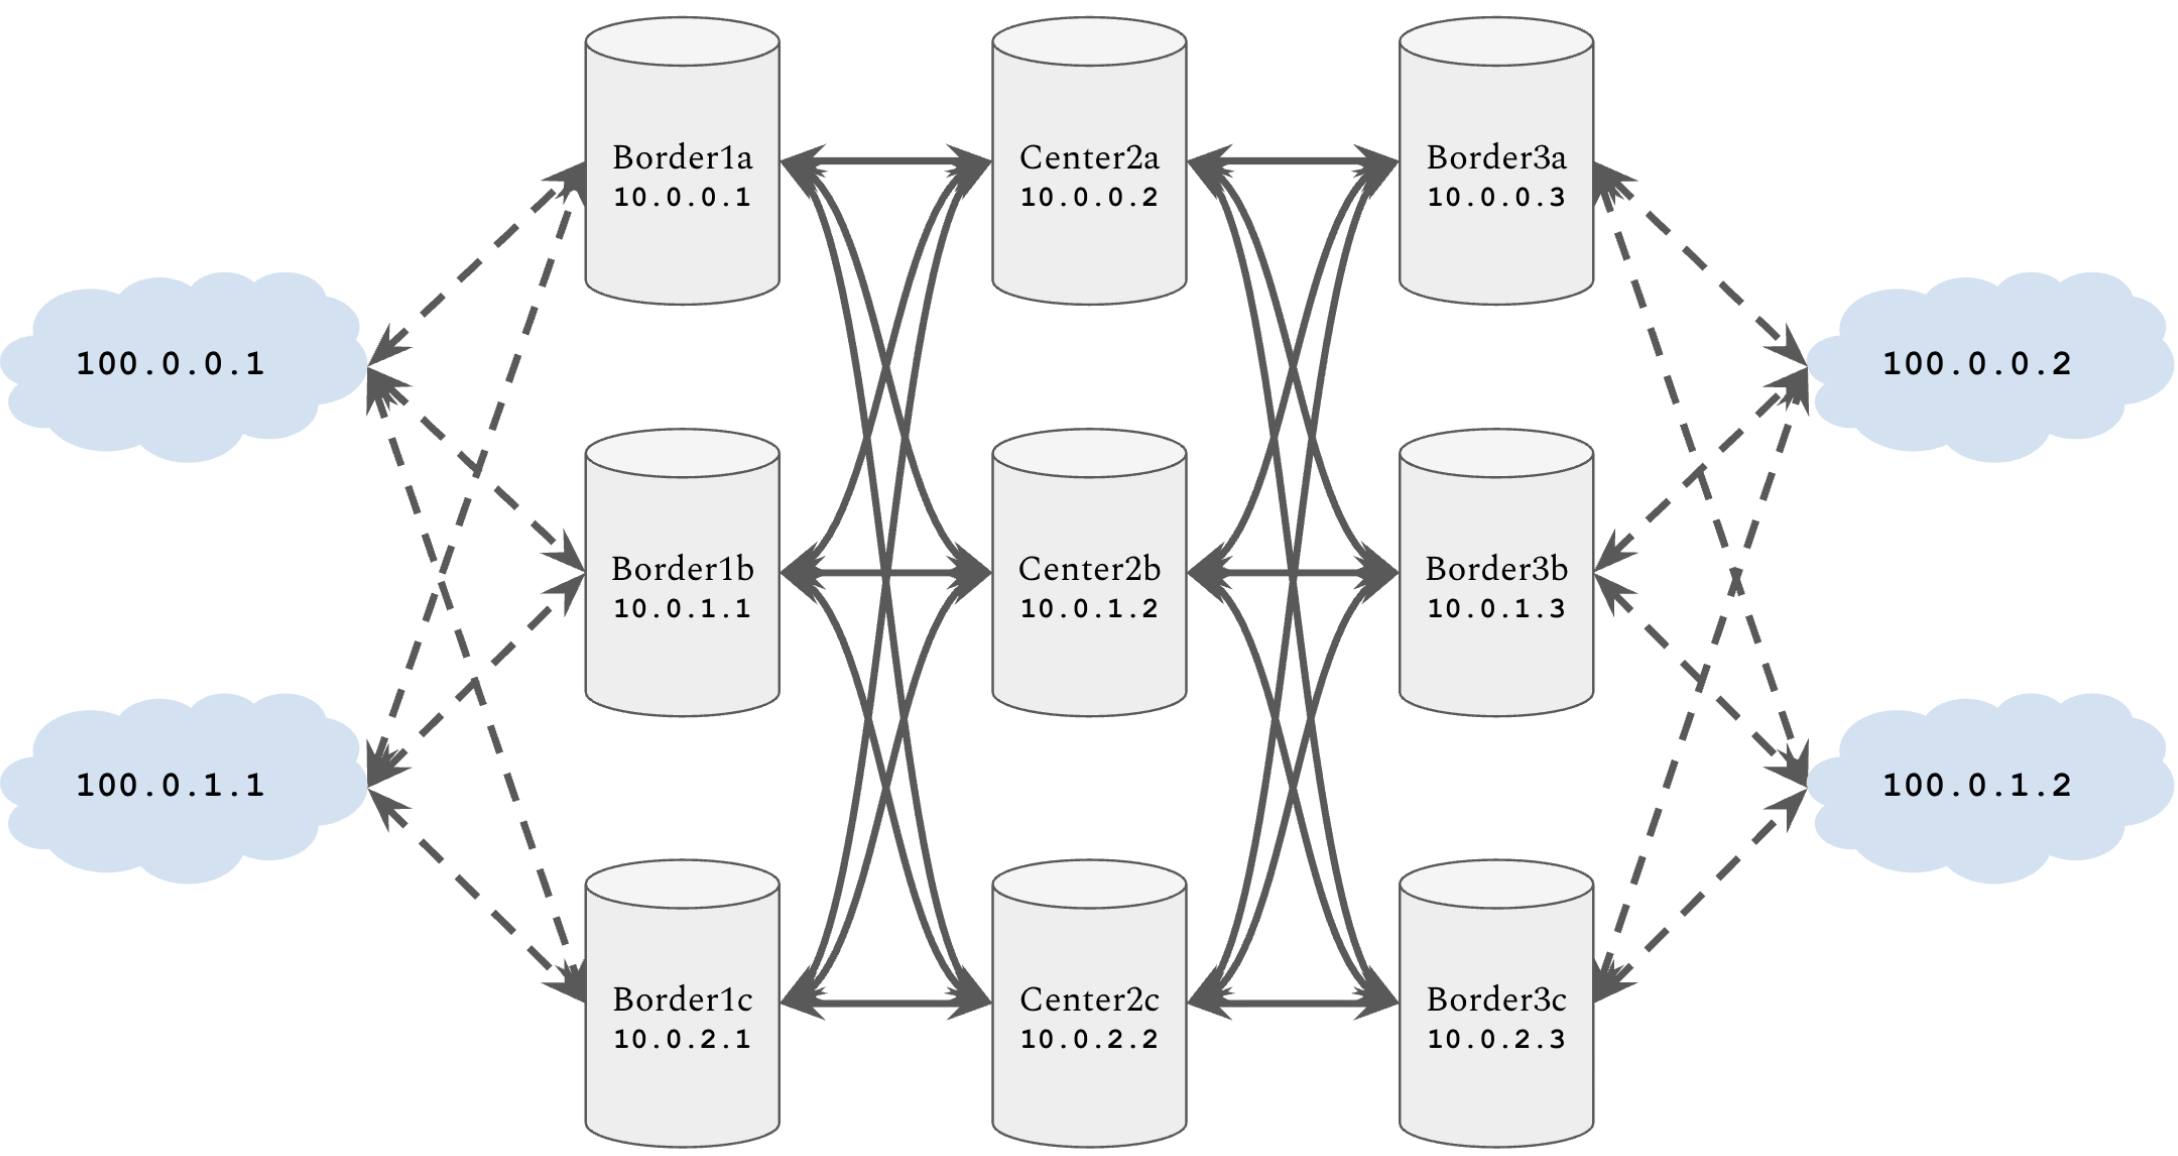

In this case there are six different outgoing edges from the third layer which we want to verify a property about (the same property). Currently, the `verify` question API does not support multiple target properties to verify - so you can run each individually to see they are all true. This feature will be added soon after initial testing.

_Note:_ This is the first example we'll show where the BDD for some invariant that we infer is too complicated for us to display. It isn't that the invariant itself is too long or complicated, but that translating the BDD to an understandable string is too inefficient. This current feature is a work in progress, and in the current version, we make a best effort attempt otherwise report the limitation (seen below as "LIMIT (Complex BDD)").

In [10]:
networkName = "exampleThree_network"
snapshotName = "exampleThree_snapshot"
snapshotPath = "snapshots/exampleThree"

target = LocationPropertyPair(location="border3a -> 100.0.0.2",property=[Clause(communities=[],prefixes=["25.13.0.0/16:16-32","!25.13.17.0/24:24-32"])])

query = VerificationQuery(target=target,assumptions=[],refine=True)
runAndDisplay(networkName,snapshotName,snapshotPath,query,show_all=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,"!prefix([25.13.17.0/24:24-32]),prefix([25.13.0.0/16:16-32])",border3a -> 100.0.0.2,"!prefix([25.13.17.0/24:24-32]),prefix([25.13.0.0/16:16-32])",
1,Assumption,true,"100.0.1.1 -> border1a, 100.0.1.1 -> border1b, 100.0.1.2 -> border3c, 100.0.1.1 -> border1c, 100.0.1.2 -> border3b, 100.0.1.2 -> border3a, 100.0.0.2 -> border3c, 100.0.0.1 -> border1a, 100.0.0.1 -> border1c, 100.0.0.1 -> border1b, 100.0.0.2 -> border3a, 100.0.0.2 -> border3b",true,
2,Intermediate,,"border1a, border1b, border1c",!comm(20:20),
3,Intermediate,,"center2b -> border1b, center2a -> border3b, center2a -> border1a, center2b -> border1a, center2a -> border3c, center2b -> border3c, center2b -> border1c, center2c -> border3b, center2c -> border1a, center2c -> border3c, center2c -> border1b, center2c -> border1c, border3b, border3c, center2a -> border1b, center2b -> border3b, center2a -> border1c",true,
4,Intermediate,,"border1a -> center2c, border1a -> center2b, border1b -> center2a, border1c -> center2c, border1b -> center2b, border1c -> center2b, border1c -> center2a, border1b -> center2c, border1a -> center2a",LIMIT (Complex BDD) [2],
5,Intermediate,,"border3b -> center2b, border3a -> center2a, border3b -> center2a, border3a -> center2b, border3c -> center2b, border3a -> center2c, border3c -> center2c, border3c -> center2a, border3b -> center2c",no traffic,
6,Intermediate,,"center2a -> border3a, center2b, center2a, center2c, border3a, center2c -> border3a, center2b -> border3a",LIMIT (Complex BDD) [1],


## Example Four

Example four is showing what happens when there are configs provided for nodes which are not reachable from the location where the target property applies. In other words, there are configs provided which would not have an effect on the validity/verification of the target property.

First, in the cell below, we show the ability to just query for the locations in the network (edges and nodes). This is done in the jupyter notebook by simply providing a `None` to the query. The query to batfish is done by just calling the `safety()` question with no arguments provided.

In [11]:
networkName = "exampleFour_network"
snapshotName = "exampleFour_snapshot"
snapshotPath = "snapshots/exampleFour"

# Calls bf.q.safety().answer().frame() without any arguments
runAndDisplay(networkName,snapshotName,snapshotPath,None,show_all=False)

,Nodes_in_Network,Neighbors_to_Node
0,left1,"['left2', '100.0.0.1', 'left3']"
1,left2,"['left1', '100.0.0.2', 'left3']"
2,left3,"['left2', 'left1']"
3,right1,"['110.0.0.1', 'right2', 'right3']"
4,right2,"['right1', 'right3', '110.0.0.2']"
5,right3,"['right1', 'right2']"


The query below is trying to prove that any route which reaches the node `left3` must have either the prefix `200.100.0.0/16` or `75.21.9.0/24`. This verification is only effect by the cluster of nodes that make the "left" subnetwork (nodes `left`', `left2`, and `left3` plus any incoming nodes from outside the network). Thus, notice that even with the `show_all` flag marked as true, we still only return the locations which have a role in the verification.

In [12]:
networkName = "exampleFour_network"
snapshotName = "exampleFour_snapshot"
snapshotPath = "snapshots/exampleFour"

target = LocationPropertyPair(location="left3",property=[Clause(communities=[],prefixes=["200.100.0.0/16"]),Clause(communities=[],prefixes=["75.21.9.0/24"])])
query = VerificationQuery(target=target,assumptions=[],refine=True)

runAndDisplay(networkName,snapshotName,snapshotPath,query,show_all=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),left3,prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),
1,Assumption,true,"100.0.0.1 -> left1, 100.0.0.2 -> left2",true,
2,Intermediate,,"left3 -> left1, left2 -> left1, left1 -> left2, left2, left1, left3 -> left2",true,
3,Intermediate,,"left2 -> left3, left1 -> left3",prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),


Even in the query below, we provide an assumption which has no effect on the verification of the target property, so the assumption is not included in our result.

In [13]:
networkName = "exampleFour_network"
snapshotName = "exampleFour_snapshot"
snapshotPath = "snapshots/exampleFour"

target = LocationPropertyPair(location="left3",property=[Clause(communities=[],prefixes=["200.100.0.0/16"]),Clause(communities=[],prefixes=["75.21.9.0/24"])])
assumption = LocationPropertyPair(location="right2",property=[Clause(communities=[],prefixes=["!1.0.0.0/8"])])
query = VerificationQuery(target=target,assumptions=[assumption],refine=True)

runAndDisplay(networkName,snapshotName,snapshotPath,query,show_all=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),left3,prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),
1,Assumption,true,"100.0.0.1 -> left1, 100.0.0.2 -> left2",true,
2,Intermediate,,"left3 -> left1, left2 -> left1, left1 -> left2, left2, left1, left3 -> left2",true,
3,Intermediate,,"left2 -> left3, left1 -> left3",prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),


## Example Five

Example five is designed to show how the refinement can make a difference. The topology is the same as in `Example One` but the route maps are different - they include more stanzas in an effort to make the inferred invariants more complicated. This is by no means an exhaustive or sufficient test to determine the effectness of the refinement or the scalability with respect to stanza size. 

Specifically, the left border node checks for variety of prefixes and sets distinct communities for them - where on export to the middle node an additional community is set based on the communities already present on the route. A similar procedure occurs in the middle node. Finally, the right border node only lets traffic with a certain community through - this traffic should have the prefix `3.9.0.0/16`. 

In the first example below, you'll note two things: 1) verification "fails" because the ingress edge from the left (`100.0.0.1`) can have traffic which does not satisfy the invariant that was inferred, and 2) the refinement flag is false -- so refinement did not take place.


In [14]:
networkName = "exampleFive_network"
snapshotName = "exampleFive_snapshot"
snapshotPath = "snapshots/exampleFive"

target = LocationPropertyPair(location="border3 -> 100.0.0.2",property=[Clause(communities=[],prefixes=["3.9.0.0/16"])])
query = VerificationQuery(target=target,assumptions=[],refine=False)

runAndDisplay(networkName,snapshotName,snapshotPath,query,show_all=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,prefix([3.9.0.0/16]),border3 -> 100.0.0.2,prefix([3.9.0.0/16]),
1,Assumption,true,100.0.0.2 -> border3,true,
2,Assumption,true,100.0.0.1 -> border1,LIMIT (Complex BDD) [1],"Bgpv4Route{network=4.16.0.0/16, communities=CommunitySet{communities=[100:100]}}"
3,Intermediate,,"border3 -> center2, border3, center2 -> border3, center2 -> border1, border1, center2, border1 -> center2","!comm(100:100),!comm(20:20),!comm(50:50) OR !comm(20:20),!comm(50:50),comm(100:100),prefix(3.9.0.0/16) OR !comm(20:20),comm(50:50),prefix(3.9.0.0/16) OR comm(20:20),prefix(3.9.0.0/16)",


The bug in the configs was that on the left most node (`border1`) we made the community addition additive. This resulted in the possibilty of communities leaking in which would inaccurately imply (by our network's understanding) that the "good prefix" was reflected in a faulty route. So, by changing the addition of communities to be strictly setting (as opposed to additive) and stripping communities otherwise, we can verify out intended property. 

Try changing the `refine` flag to be false... you'll notice a slight change in the invariants. Without the refinement, the invariants are slightly more complex.

In [15]:
networkName = "exampleFiveFixed_network"
snapshotName = "exampleFiveFixed_snapshot"
snapshotPath = "snapshots/exampleFiveFixed"

target = LocationPropertyPair(location="border3 -> 100.0.0.2",property=[Clause(communities=[],prefixes=["3.9.0.0/16"])])
query = VerificationQuery(target=target,assumptions=[],refine=True)

runAndDisplay(networkName,snapshotName,snapshotPath,query,show_all=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,prefix([3.9.0.0/16]),border3 -> 100.0.0.2,prefix([3.9.0.0/16]),
1,Assumption,true,"100.0.0.1 -> border1, 100.0.0.2 -> border3",true,
2,Intermediate,,border1,"!comm(100:100),!comm(20:20),!comm(50:50) OR !comm(100:100),comm(20:20),prefix(3.9.0.0/16) OR !comm(20:20),!comm(50:50),comm(100:100),prefix(3.9.0.0/16)",
3,Intermediate,,"center2 -> border1, center2, border1 -> center2","!comm(100:100),!comm(20:20),!comm(50:50) OR !comm(100:100),comm(20:20),comm(50:50),prefix(3.9.0.0/16) OR !comm(20:20),!comm(50:50),comm(100:100),prefix(3.9.0.0/16)",
4,Intermediate,,"border3 -> center2, border3, center2 -> border3","!comm(100:100),!comm(20:20),!comm(50:50) OR !comm(20:20),!comm(50:50),comm(100:100),prefix(3.9.0.0/16)",


The previous refinement makes a slight change. In the following example, we use the same network (`exampleFiveFixed`) but in some of the cases where communities were checked that we didn't ever use - we changed those paths through the route map to result in a denial. This complicates our invariants as any case where a route is denied is safe.

First, run the following code below (with the refinement flag as true)... then try changing it to false. This time there should be a pretty significant difference in the invariants.

In [16]:
networkName = "exampleFiveDenies_network"
snapshotName = "exampleFiveDenies_snapshot"
snapshotPath = "snapshots/exampleFiveDenies"

target = LocationPropertyPair(location="border3 -> 100.0.0.2",property=[Clause(communities=[],prefixes=["3.9.0.0/16"])])
query = VerificationQuery(target=target,assumptions=[],refine=True)

runAndDisplay(networkName,snapshotName,snapshotPath,query,show_all=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,prefix([3.9.0.0/16]),border3 -> 100.0.0.2,prefix([3.9.0.0/16]),
1,Assumption,true,"100.0.0.1 -> border1, 100.0.0.2 -> border3",true,
2,Intermediate,,border1,"!comm(100:100),!comm(20:20),!comm(50:50) OR !comm(100:100),comm(20:20),prefix(3.9.0.0/16) OR !comm(20:20),!comm(50:50),comm(100:100),prefix(3.9.0.0/16)",
3,Intermediate,,"center2 -> border1, center2, border1 -> center2","!comm(100:100),!comm(20:20),!comm(50:50) OR !comm(100:100),comm(20:20),comm(50:50),prefix(3.9.0.0/16) OR !comm(20:20),!comm(50:50),comm(100:100),prefix(3.9.0.0/16)",
4,Intermediate,,"border3 -> center2, border3, center2 -> border3","!comm(100:100),!comm(20:20),!comm(50:50) OR !comm(20:20),!comm(50:50),comm(100:100),prefix(3.9.0.0/16)",
